# 06 Modellsammenligning, K-fold og grid search
*Data Mining & Analytics – Samling 2, dag 2*


In [8]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"      # fjerner en unødvendig advarsel fra joblib på Windows

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42)

In [ ]:
from sklearn.metrics import confusion_matrix

def klassifiserings_metrikker(y_sann, y_pred):
    """Metrikker for binær klassifisering (positiv klasse = 1)."""
    tn, fp, fn, tp = confusion_matrix(y_sann, y_pred, labels=[0, 1]).ravel()
    return {"nøyaktighet": (tp + tn) / (tp + tn + fp + fn),
            "sensitivitet": tp / (tp + fn) if tp + fn else np.nan,
            "spesifisitet": tn / (tn + fp) if tn + fp else np.nan,
            "presisjon": tp / (tp + fp) if tp + fp else np.nan,
            "F1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else np.nan}

In [10]:
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

titanic = pd.read_csv("../Data/titanic.csv")
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X, y = titanic[features], titanic["survived"]
print("Antall:", len(y))
print("Andel overlevende:", y.mean().round(3))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

Antall: 891
Andel overlevende: 0.384


## Preprosessering i pipeline (imputering + koding – kun lært fra treningsfoldene)

In [11]:
num = ["age", "sibsp", "parch", "fare"]; kat = ["pclass", "sex", "embarked"]
prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
    ("kat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore"))]), kat),
])
pipes = {
    "Baseline": DummyClassifier(strategy="prior"),
    "Logistisk regresjon": LogisticRegression(max_iter=2000),
    "kNN": KNeighborsClassifier(15),
    "Random forest": RandomForestClassifier(300, min_samples_leaf=3, random_state=0),
    "Gradient boosting": HistGradientBoostingClassifier(random_state=0),
}
pipes = {n: Pipeline([("prep", prep), ("m", m)]) for n, m in pipes.items()}

## Repetert stratifisert K-fold (5 × 5)

                     F1 snitt  F1 SD  AUC snitt  AUC SD
Gradient boosting       0.758  0.049      0.870   0.034
kNN                     0.748  0.040      0.853   0.038
Random forest           0.743  0.046      0.870   0.036
Logistisk regresjon     0.734  0.047      0.852   0.043
Baseline                0.000  0.000      0.500   0.000


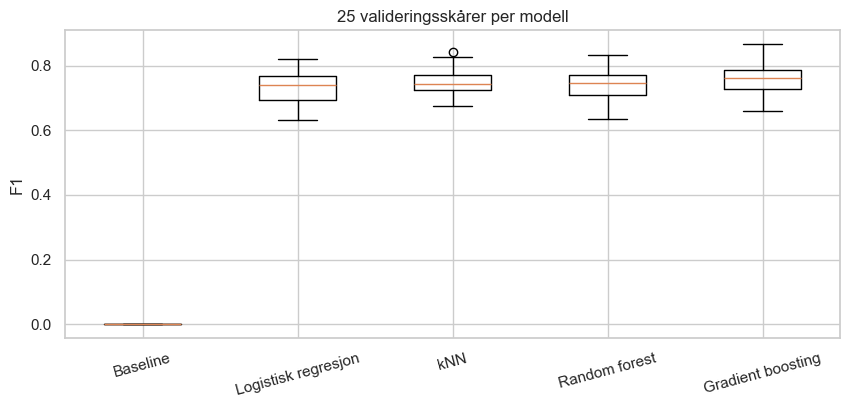

In [12]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)
f1 = {n: cross_val_score(p, X_train, y_train, cv=cv, scoring="f1") for n, p in pipes.items()}
auc = {n: cross_val_score(p, X_train, y_train, cv=cv, scoring="roc_auc") for n, p in pipes.items()}
tab = pd.DataFrame({"F1 snitt": {n: s.mean() for n, s in f1.items()}, "F1 SD": {n: s.std() for n, s in f1.items()},
                    "AUC snitt": {n: s.mean() for n, s in auc.items()}, "AUC SD": {n: s.std() for n, s in auc.items()}}).round(3)
print(tab.sort_values("F1 snitt", ascending=False))

plt.figure(figsize=(10, 4))
plt.boxplot(list(f1.values()), tick_labels=list(f1.keys()))
plt.ylabel("F1")
plt.xticks(rotation=15)
plt.title("25 valideringsskårer per modell")
plt.show()

### Er forskjellen «signifikant»? Korrigert paret t-test (Nadeau–Bengio)

Foldene overlapper i treningsdata, så den vanlige t-testen er ofte litt for optimistisk (ref gårsdagen).

In [13]:
def korrigert_ttest(a, b, n_test_over_train=1 / 4):
    d = np.asarray(a) - np.asarray(b)
    J = len(d)
    t = d.mean() / np.sqrt((1 / J + n_test_over_train) * d.var())
    return d.mean(), t, 2 * stats.t.sf(abs(t), J - 1)

ref = "Logistisk regresjon"
for n in ["kNN", "Random forest", "Gradient boosting"]:
    d, t, p = korrigert_ttest(f1[n], f1[ref])
    uten_korreksjon = stats.ttest_rel(f1[n], f1[ref]).pvalue
    print(f"{n:18s} − {ref}:   delta F1 = {d:+.3f}   p-verdi uten korreksjon = {uten_korreksjon:.4f}   korrigert p-verdi = {p:.3f}")

kNN                − Logistisk regresjon:   delta F1 = +0.014   p-verdi uten korreksjon = 0.0706   korrigert p-verdi = 0.480
Random forest      − Logistisk regresjon:   delta F1 = +0.010   p-verdi uten korreksjon = 0.2193   korrigert p-verdi = 0.637
Gradient boosting  − Logistisk regresjon:   delta F1 = +0.025   p-verdi uten korreksjon = 0.0055   korrigert p-verdi = 0.259


## Hyperparametersøk (GridSearchCV) og nested CV

GridSearchCV velger hyperparametere ved kryssvalidering. Ved lite data og enklere tabelldatasett kan det praktisk gjennomførbart å gjøre "nested" kryssvalidering, hvor indre løkke finner beste hyperparametre og ytre løkke evaluerer hele beste paramterer på et usett valideringssett.

In [14]:
rf = Pipeline([("prep", prep), ("m", RandomForestClassifier(300, random_state=0))])
grid = {"m__max_depth": [3, 5, 8, None], "m__min_samples_leaf": [1, 3, 8], "m__max_features": ["sqrt", 0.5]}
inner = StratifiedKFold(5, shuffle=True, random_state=1)
gs = GridSearchCV(rf, grid, cv=inner, scoring="roc_auc", n_jobs=1).fit(X_train, y_train)
print("Beste parametere:", gs.best_params_)
print(f"Beste CV-AUC (optimistisk): {gs.best_score_:.3f}")

ytre = StratifiedKFold(5, shuffle=True, random_state=2)
nested = cross_val_score(GridSearchCV(rf, grid, cv=inner, scoring="roc_auc"), X_train, y_train, cv=ytre, scoring="roc_auc")
print(f"Nested ROC:     {nested.mean():.3f} ± {nested.std():.3f}")

Beste parametere: {'m__max_depth': None, 'm__max_features': 0.5, 'm__min_samples_leaf': 3}
Beste CV-AUC (optimistisk): 0.875
Nested ROC:     0.862 ± 0.026
